In [39]:
import cv2 as cv
from cv2 import aruco

import numpy as np

import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 150

src_coords = (np.array([[   [ 0.,  0.],  [60., 0.],   [60., 60.],  [ 0.,60.], 
                            [ 0., 172.], [60., 172.], [60., 232.], [ 0., 232.]]], dtype= np.float32) )

src_coords

array([[[  0.,   0.],
        [ 60.,   0.],
        [ 60.,  60.],
        [  0.,  60.],
        [  0., 172.],
        [ 60., 172.],
        [ 60., 232.],
        [  0., 232.]]], dtype=float32)

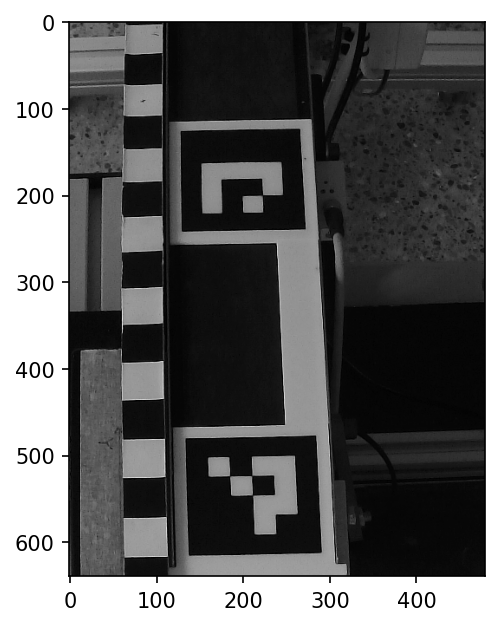

In [40]:
img = cv.imread("test_aruco.png")
img_rotated = cv.rotate(img, 2)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

gray_rotated = cv.rotate(gray, 2)

fig = plt.imshow(gray_rotated, cmap = 'gray', vmin=0, vmax=255)

In [41]:
aruco_dict = aruco.getPredefinedDictionary(cv.aruco.DICT_4X4_100)
parameters = aruco.DetectorParameters()
detector = aruco.ArucoDetector(aruco_dict, parameters)
corners, ids, rejected = detector.detectMarkers(gray_rotated)

corners

(array([[[135., 481.],
         [284., 478.],
         [291., 612.],
         [138., 615.]]], dtype=float32),
 array([[[129., 127.],
         [266., 125.],
         [272., 240.],
         [130., 242.]]], dtype=float32))

In [42]:
if len(ids) > 0:
    img_markers = img_rotated.copy()
    aruco.drawDetectedMarkers(img_markers, corners, ids)
    
    for i, corner in enumerate(corners):
        top_left = corner[0][0]  # corner[marker][punkt][x/y]
        cv.putText(img_markers, str(ids[i][0]),
                   (int(top_left[0]) - 10, int(top_left[1]) - 10),
                   cv.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
    
    #cv.imshow("Detected Markers", img_markers)
    #cv.waitKey(0)
    #cv.destroyAllWindows()
else:
    print("Keine Marker erkannt!")

        H, status = cv2.findHomography(pts_img, pts_world)



(np.float64(-0.5), np.float64(479.5), np.float64(639.5), np.float64(-0.5))

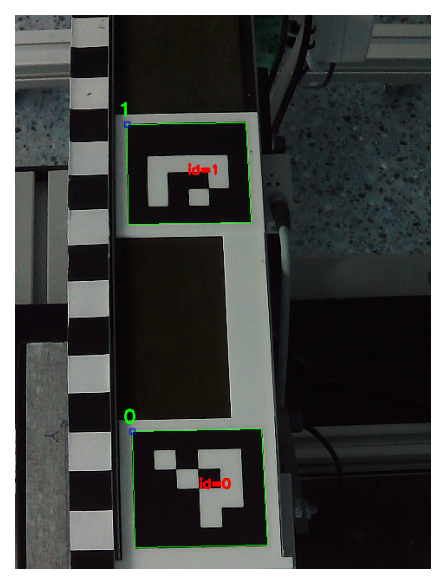

In [43]:
fig = plt.imshow(img_markers, cmap = 'gray', vmin=0, vmax=255)
plt.axis('off')

In [44]:
dstPoints = np.concatenate(corners, axis=1)

H, status = cv.findHomography(srcPoints=src_coords, dstPoints=dstPoints, method=0)
H, status ,corners, dstPoints

(array([[ 2.60664281e+00,  4.86697644e-02,  1.33621292e+02],
        [-2.12632849e-02, -1.56899769e+00,  5.62685398e+02],
        [ 1.06194299e-04,  4.67233527e-04,  1.00000000e+00]]),
 array([[0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0]], dtype=uint8),
 (array([[[135., 481.],
          [284., 478.],
          [291., 612.],
          [138., 615.]]], dtype=float32),
  array([[[129., 127.],
          [266., 125.],
          [272., 240.],
          [130., 242.]]], dtype=float32)),
 array([[[135., 481.],
         [284., 478.],
         [291., 612.],
         [138., 615.],
         [129., 127.],
         [266., 125.],
         [272., 240.],
         [130., 242.]]], dtype=float32))

        pixel = np.array([[[800.0, 560.0]]], dtype=np.float32)

        world = cv2.perspectiveTransform(pixel, H)

        X, Y = world[0,0,0], world[0,0,1]

In [45]:
pixel_cam = np.array([[[283.0, 451.0]]], dtype=np.float32)
world = cv.perspectiveTransform(pixel_cam, H)
X, Y = world[0,0,0], world[0,0,1]

In [46]:
world

array([[[ 719.9138 , -121.65786]]], dtype=float32)

In [47]:
H_inv = np.linalg.inv(H)
world_inv = cv.perspectiveTransform(pixel_cam, H_inv)
world_inv

array([[[59.934917, 60.425507]]], dtype=float32)

In [48]:
H_inv, H

(array([[ 3.85644513e-01, -2.89724088e-03, -4.99000831e+01],
        [-1.70554124e-02, -5.45752246e-01,  3.09365786e+02],
        [-3.29843881e-05,  2.55301417e-04,  8.60753037e-01]]),
 array([[ 2.60664281e+00,  4.86697644e-02,  1.33621292e+02],
        [-2.12632849e-02, -1.56899769e+00,  5.62685398e+02],
        [ 1.06194299e-04,  4.67233527e-04,  1.00000000e+00]]))